In [ ]:
import pandas as pd
import numpy as np
# 1- Create the DataFrame
data = {
    "Student": ["S1", "S2", "S3", "S4", "S5"],
    "StudyHours": [2, 3, np.nan, 5, 6],
    "Marks": [35, 40, 45, np.nan, 70]
}

df = pd.DataFrame(data)
print("DataFrame:")
print(df)
print(df.isnull())
df["StudyHours"].fillna(df["StudyHours"].mean(), inplace=True)
print("\nDataFrame after replacing missing values with mean:")
print(df)

DataFrame:
  Student  StudyHours  Marks
0      S1         2.0   35.0
1      S2         3.0   40.0
2      S3         NaN   45.0
3      S4         5.0    NaN
4      S5         6.0   70.0
   Student  StudyHours  Marks
0    False       False  False
1    False       False  False
2    False        True  False
3    False       False   True
4    False       False  False

DataFrame after replacing missing values with mean:
  Student  StudyHours  Marks
0      S1         2.0   35.0
1      S2         3.0   40.0
2      S3         NaN   45.0
3      S4         5.0    NaN
4      S5         6.0   70.0


C:\Users\Jayshri\AppData\Local\Temp\ipykernel_10180\2335171532.py:21: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["StudyHours"].fillna(df["StudyHours"].mean(), inplace=True)


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

data = {
    "StudyHours": [2,3,4,5,6,7,8,9,10,11],
    "Marks": [35,40,45,50,55,60,65,70,75,80]
}

df = pd.DataFrame(data)
print(df.head())
print(df.info())
print(df.isnull().anyvalue)
X = df[["StudyHours"]]
y = df["Marks"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = LinearRegression()
model.fit(X_train, y_train)
print("\nCoefficient:", model.coef_)
print("Intercept:", model.intercept_)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("\nMean Squared Error:", mse)

First five rows:
   StudyHours  Marks
0           2     35
1           3     40
2           4     45
3           5     50
4           6     55

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   StudyHours  10 non-null     int64
 1   Marks       10 non-null     int64
dtypes: int64(2)
memory usage: 292.0 bytes
None

Missing values:
StudyHours    0
Marks         0
dtype: int64

Coefficient: [5.]
Intercept: 25.0

Mean Squared Error: 0.0


Accuracy: 1.0


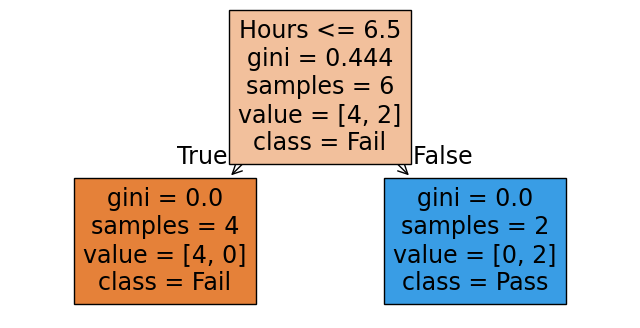

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Dataset
data = {
    "Hours":[1,2,3,4,5,6,7,8],
    "Marks":[20,30,35,50,55,60,70,80],
    "Result":[0,0,0,0,0,0,1,1]  
}

df = pd.DataFrame(data)
X = df[["Hours","Marks"]]
y = df["Result"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
plt.figure(figsize=(8,4))
plot_tree(model,
        feature_names=["Hours","Marks"],
        class_names=["Fail","Pass"],
        filled=True)

plt.show()